In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from matplotlib.ticker import FixedLocator

files = {
    'Native': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/native/summary_final.csv',
    'SEV': '/home/mengelsl/MA-bench-framework/outputs/spmv/_new/sev/summary_final.csv',
}
#csv header:
#NUMA_Policy,Boost,NUMA_Balancing,Matrix,Cores,Run,Iterations,Intern_Runtime,Intern_Gflops,Perf_DurationTime,Perf_Insn,Perf_Cycl,Perf_CacheMisses,Perf_dTLBLoadMisses

matrix_path = '../../matrices/spmv_synthetic/'

def get_mb(row):
    r_str = str(row['Randomness']).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(row['N'])}.bin")
    return os.path.getsize(f_path) / (1024**2) if os.path.exists(f_path) else None

def get_n(f):
    m = re.search(r'N(\d+)', f)
    return int(m.group(1)) if m else 0

def get_rand(f):
    m = re.search(r'(\d)-(\d)', f)
    return float(f"{m.group(1)}.{m.group(2)}") if m else 0.0

def load_and_process(label, path):
    df = pd.read_csv(path)
    df['Mode'] = label
    df['N'] = df['Matrix'].apply(get_n)
    df['Randomness'] = df['Matrix'].apply(get_rand)
    df['MB'] = df.apply(get_mb, axis=1).round().astype('Int64')
    return df

df_list = [load_and_process(l, p) for l, p in files.items()]
df_raw = pd.concat([d for d in df_list if d is not None])

group_cols = ['Mode', 'Cores', 'MB', 'Randomness']
metrics = ['Intern_Runtime', 'Intern_Gflops', 'Perf_DurationTime', 'Perf_Insn', 'Perf_Cycl', 'Perf_CacheMisses', 'Perf_dTLBLoadMisses']

df = df_raw.groupby(group_cols)[metrics].median().reset_index()

variance = df_raw.groupby(group_cols)['Intern_Runtime'].var().reset_index()

df['Intern_Runtime_CV'] = (np.sqrt(variance['Intern_Runtime_Var']))/ df['Intern_Runtime']) * 100

In [25]:
df[df["Intern_Runtime_Var"] > 0.05]

,Mode,Cores,MB,Randomness,Intern_Runtime,Intern_Gflops,Perf_DurationTime,Perf_Insn,Perf_Cycl,Perf_CacheMisses,Perf_dTLBLoadMisses,Intern_Runtime_Var
51,Native,8,20,0.0,5.00701,16.519300,5.020404e+09,5.212424e+11,9.399557e+10,4.044237e+07,57010.0,0.061558
89,Native,24,300,1.0,5.02097,17.056400,5.106642e+09,5.403637e+11,2.826674e+11,3.836100e+10,84820.0,0.086948
161,SEV,1,300,1.0,4.90037,0.994406,5.237393e+09,3.081077e+10,1.152214e+10,2.168880e+09,131997.0,0.054235
173,SEV,4,20,1.0,5.26737,5.849270,5.280788e+09,1.941685e+11,4.940171e+10,6.241204e+08,36016.0,0.083652
197,SEV,8,20,1.0,4.81057,11.865400,4.824224e+09,3.597944e+11,9.027331e+10,9.841146e+08,38664.0,0.072754
232,SEV,24,300,0.5,5.05312,16.640100,5.139948e+09,5.310782e+11,2.843375e+11,1.995692e+10,80837.0,0.123782
233,SEV,24,300,1.0,5.47213,15.650100,5.559300e+09,5.401677e+11,3.080276e+11,4.168782e+10,86346.0,0.185970
257,SEV,48,300,1.0,4.17315,29.155100,4.273550e+09,7.696164e+11,4.686225e+11,5.649682e+10,312083.0,0.338214
284,SEV,96,764,1.0,6.81956,20.227100,7.031566e+09,8.978174e+11,1.533067e+12,7.043430e+10,1814137.0,0.086401
286,SEV,96,1909,0.5,6.10321,9.300030,6.596356e+09,3.751241e+11,1.325535e+12,1.489530e+10,5003837.0,0.163416


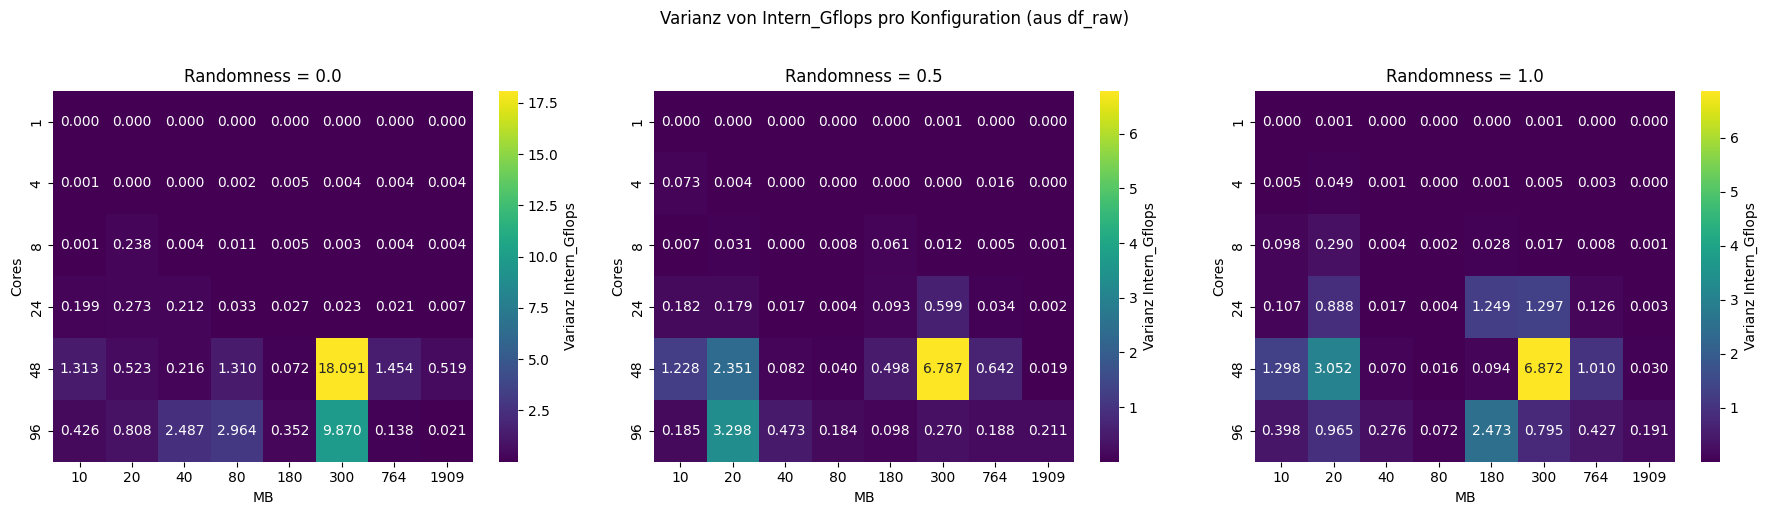

In [ ]:
# Native vs SEV runtime heatmaps + SEV delta [%] for each Randomness
unique_randomness = sorted(df['Randomness'].dropna().unique())

fig, axes = plt.subplots(
	len(unique_randomness), 3,
	figsize=(16, 4.5 * len(unique_randomness)),
	squeeze=False
)

# global color scale for fair Native/SEV comparison
runtime_min = df['Intern_Runtime'].min()
runtime_max = df['Intern_Runtime'].max()

for i, rnd in enumerate(unique_randomness):
	native = df[(df['Mode'] == 'Native') & (df['Randomness'] == rnd)].pivot_table(
		index='Cores', columns='MB', values='Intern_Runtime', observed=False
	)
	sev = df[(df['Mode'] == 'SEV') & (df['Randomness'] == rnd)].pivot_table(
		index='Cores', columns='MB', values='Intern_Runtime', observed=False
	)
	delta = (sev / native - 1) * 100

	sns.heatmap(
		native, ax=axes[i, 0], cmap='YlGnBu', annot=True, fmt='.2f',
		vmin=runtime_min, vmax=runtime_max, cbar_kws={'label': 'Intern_Runtime'}
	)
	axes[i, 0].set_title(f'Native (Randomness={rnd})')
	axes[i, 0].set_xlabel('MB')
	axes[i, 0].set_ylabel('Cores')

	sns.heatmap(
		sev, ax=axes[i, 1], cmap='YlGnBu', annot=True, fmt='.2f',
		vmin=runtime_min, vmax=runtime_max, cbar_kws={'label': 'Intern_Runtime'}
	)
	axes[i, 1].set_title(f'SEV (Randomness={rnd})')
	axes[i, 1].set_xlabel('MB')
	axes[i, 1].set_ylabel('')

	sns.heatmap(
		delta, ax=axes[i, 2], cmap='RdYlGn_r', center=0, annot=True, fmt='+.1f',
		cbar_kws={'label': 'SEV vs Native [%]'}
	)
	axes[i, 2].set_title(f'Delta % (Randomness={rnd})')
	axes[i, 2].set_xlabel('MB')
	axes[i, 2].set_ylabel('')

plt.tight_layout()
plt.show()
unique_randomness = sorted(varianz_pro_config['Randomness'].dropna().unique())
fig, axes = plt.subplots(1, len(unique_randomness), figsize=(6 * len(unique_randomness), 5), squeeze=False)

for j, rnd in enumerate(unique_randomness):
	ax = axes[0, j]
	p = (
		varianz_pro_config[varianz_pro_config['Randomness'] == rnd]
		.pivot_table(index='Cores', columns='MB', values='Var_Intern_Gflops', observed=False)
	)

	sns.heatmap(
		p,
		ax=ax,
		cmap='viridis',
		annot=True,
		fmt='.3f',
		cbar_kws={'label': 'Varianz Intern_Gflops'}
	)
	ax.set_title(f'Randomness = {rnd}')
	ax.set_xlabel('MB')
	ax.set_ylabel('Cores')

plt.suptitle('Varianz von Intern_Gflops pro Konfiguration (aus df_raw)', y=1.02)
plt.tight_layout()
plt.show()

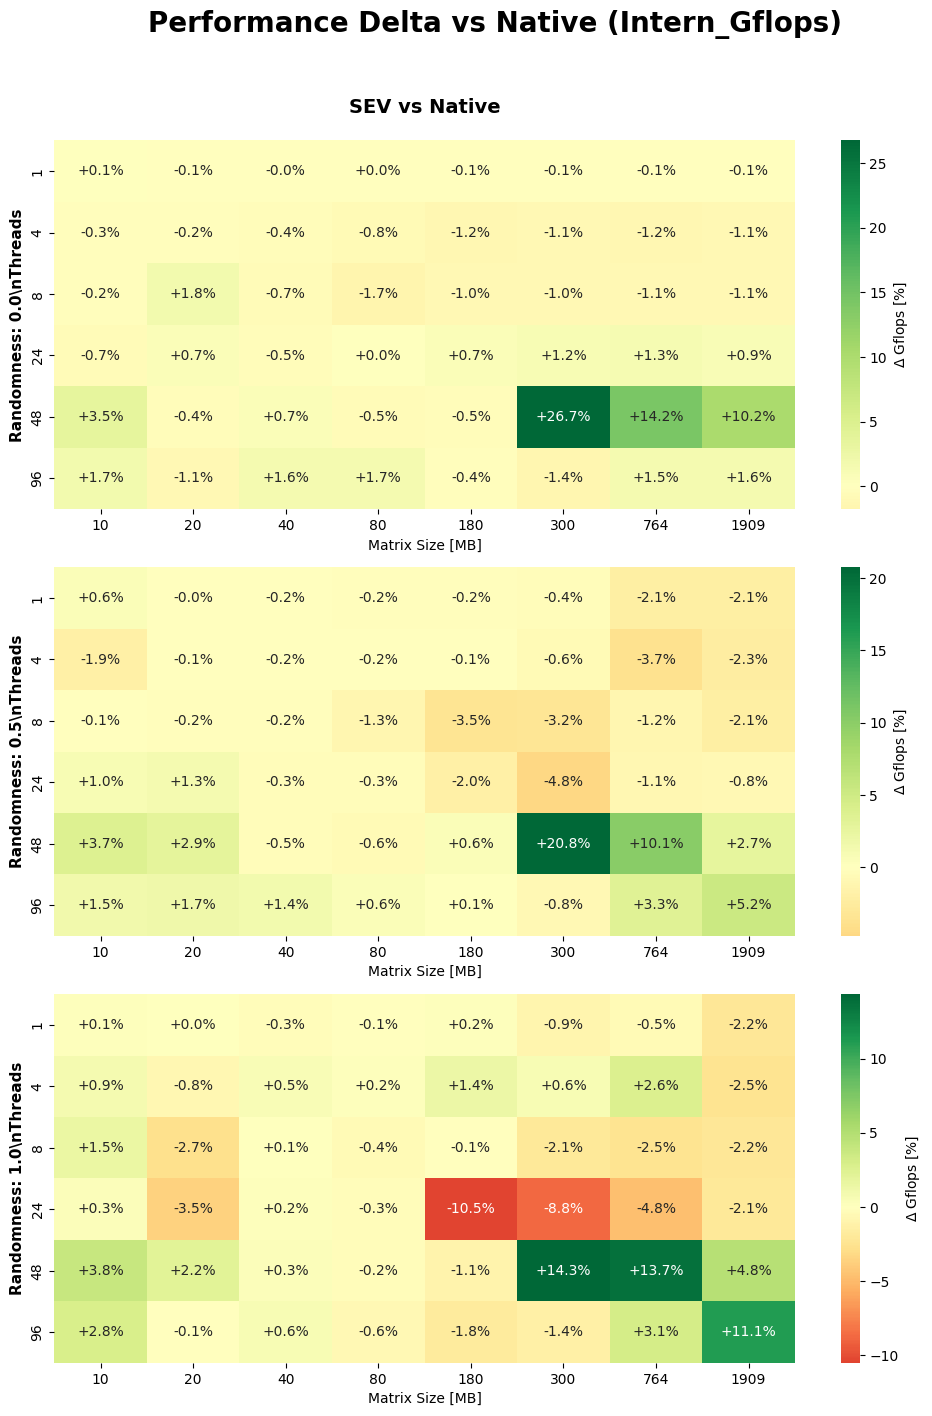

In [6]:
# Build a mode-aware table from the same sources used above
mode_frames = []
for mode, path in files.items():
    tmp = load_and_process(mode, path)
    if tmp is None:
        continue
    tmp['Mode'] = mode
    mode_frames.append(tmp)

if not mode_frames:
    raise ValueError("No valid CSV files found. Check the paths in 'files'.")

mode_df = pd.concat(mode_frames, ignore_index=True)

heat_pivot = agg.pivot_table(
    index=['Cores', 'MB', 'Randomness'],
    columns='Mode',
    values='Intern_Gflops',
    observed=False
).reset_index()

if 'Native' not in heat_pivot.columns:
    raise ValueError("Column 'Native' is required to compute delta vs Native.")

non_native_modes = [m for m in files.keys() if m != 'Native' and m in heat_pivot.columns]
if not non_native_modes:
    raise ValueError("No non-native modes available for delta plotting.")

for mode in non_native_modes:
    col_name = f'{mode}_vs_Nat_%'
    heat_pivot[col_name] = (heat_pivot[mode] / heat_pivot['Native'] - 1) * 100

heat_pivot = heat_pivot.sort_values(by=['Cores'])
heat_pivot['Threads_Config'] = heat_pivot['Cores'].astype(str)
config_order = heat_pivot['Threads_Config'].unique()
heat_pivot['Threads_Config'] = pd.Categorical(
    heat_pivot['Threads_Config'],
    categories=config_order,
    ordered=True
)

modes_to_plot = [f'{m}_vs_Nat_%' for m in non_native_modes]
mode_titles = [m.replace('_', ' ').upper() + " vs Native" for m in non_native_modes]
unique_randomness = sorted(heat_pivot['Randomness'].dropna().unique())

n_rows = max(1, len(unique_randomness))
n_cols = len(modes_to_plot)
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(max(10, 5 * n_cols), 4.8 * n_rows),
    squeeze=False
)

for i, rnd in enumerate(unique_randomness):
    row_data = heat_pivot[heat_pivot['Randomness'] == rnd]

    for j, (m_col, title) in enumerate(zip(modes_to_plot, mode_titles)):
        ax = axes[i, j]

        if row_data.empty or m_col not in row_data.columns:
            ax.set_visible(False)
            continue

        plot_data = row_data.pivot_table(
            index='Threads_Config',
            columns='MB',
            values=m_col,
            sort=False,
            observed=False
        )

        sns.heatmap(
            plot_data,
            ax=ax,
            cmap='RdYlGn',
            center=0,
            annot=True,
            fmt='+.1f',
            cbar_kws={'label': '$\\Delta$ Gflops [%]'}
        )

        for text in ax.texts:
            t_val = text.get_text()
            if t_val and t_val != 'nan':
                text.set_text(f"{t_val}%")

        if i == 0:
            ax.set_title(title, fontsize=14, fontweight='bold', pad=20)

        if j == 0:
            ax.set_ylabel(f"Randomness: {rnd}\\nThreads", fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel("")

        ax.set_xlabel("Matrix Size [MB]")

plt.suptitle("Performance Delta vs Native (Intern_Gflops)", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()